In [4]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

In [5]:
import pickle, os

with open('data/data_churn_final.pkl', 'rb') as f:
    X_treino, X_teste, y_treino, y_teste = pickle.load(f)

In [6]:
RandomForest = RandomForestClassifier()
RandomForest.fit(X_treino, y_treino)
y_pred_rf = RandomForest.predict(X_teste)
accuracy_score(y_teste,y_pred_rf)


0.7803837953091685

In [7]:
svm = SVC()
svm.fit(X_treino, y_treino)
y_pred_svm = svm.predict(X_teste)
accuracy_score(y_teste,y_pred_svm)

0.783226723525231

In [8]:
rede_neural = MLPClassifier( hidden_layer_sizes=(100, 50), activation = 'relu', solver='adam', max_iter=1000)
rede_neural.fit(X_treino, y_treino)
y_pred_MLP = rede_neural.predict(X_teste)
accuracy_score(y_teste,y_pred_MLP)

0.7455579246624022

In [9]:
knn = KNeighborsClassifier()
knn.fit(X_treino, y_treino)
y_pred_knn = knn.predict(X_teste)
accuracy_score(y_teste,y_pred_knn)


0.7469793887704336

In [10]:
log_regression = LogisticRegression()
log_regression.fit(X_treino, y_treino)
y_pred_log = log_regression.predict(X_teste)
accuracy_score(y_teste,y_pred_log)


0.7889125799573561

In [11]:
naive_bayes = GaussianNB()
naive_bayes.fit(X_treino, y_treino)
y_pred_nb = naive_bayes.predict(X_teste)
accuracy_score(y_teste,y_pred_nb)

0.6837242359630419

#Tuning de parametros

In [10]:
from sklearn.model_selection import GridSearchCV

In [11]:
X_churn = np.concatenate((X_treino, X_teste), axis=0)
y_churn = np.concatenate((y_treino, y_teste), axis=0)

X_churn.shape, y_churn.shape

((7032, 45), (7032,))

Random Forest

In [12]:
parametros = {'criterion': ['gini', 'entropy'],
              'n_estimators': [10, 40, 100, 150],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 5, 10]}

In [13]:
grid_search = GridSearchCV(estimator=RandomForestClassifier(), param_grid=parametros)
grid_search.fit(X_churn, y_churn)
melhores_parametros = grid_search.best_params_
melhores_resultados = grid_search.best_score_
print("Melhores Parâmetros:", melhores_parametros)
print("Melhor Resultado:", melhores_resultados)


Melhores Parâmetros: {'criterion': 'gini', 'min_samples_leaf': 10, 'min_samples_split': 5, 'n_estimators': 150}
Melhor Resultado: 0.8033281064702903


SVM

In [14]:
parametros = {'tol': [0.001, 0.0001, 0.00001],
              'C': [1.0, 1.5, 2.0],
              'kernel': ['rbf', 'linear', 'poly', 'sigmoid']}

In [15]:
grid_search = GridSearchCV(estimator=SVC(), param_grid=parametros)
grid_search.fit(X_churn, y_churn)
melhores_parametros = grid_search.best_params_
melhores_resultados = grid_search.best_score_
print("Melhores Parâmetros:", melhores_parametros)
print("Melhor Resultado:", melhores_resultados)

Melhores Parâmetros: {'C': 2.0, 'kernel': 'linear', 'tol': 0.001}
Melhor Resultado: 0.7990632086468693


Rede Neural

In [16]:
parametros = {'activation': ['relu', 'logistic', 'tahn'],
              'solver': ['adam', 'sgd'],
              'batch_size': [10, 56]}

In [17]:
grid_search = GridSearchCV(estimator=MLPClassifier(), param_grid=parametros)
grid_search.fit(X_churn, y_churn)
melhores_parametros = grid_search.best_params_
melhores_resultados = grid_search.best_score_
print("Melhores Parâmetros:", melhores_parametros)
print("Melhor Resultado:", melhores_resultados)

c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\sit

Melhores Parâmetros: {'activation': 'logistic', 'batch_size': 10, 'solver': 'sgd'}
Melhor Resultado: 0.8004840661557079


KNN

In [18]:
parametros = {'n_neighbors': [3, 5, 10, 20],
              'p': [1, 2]}

In [19]:
grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parametros)
grid_search.fit(X_churn, y_churn)
melhores_parametros = grid_search.best_params_
melhores_resultados = grid_search.best_score_
print("Melhores Parâmetros:", melhores_parametros)
print("Melhor Resultado:", melhores_resultados)

Melhores Parâmetros: {'n_neighbors': 20, 'p': 1}
Melhor Resultado: 0.7827077779159476


Regressão Logistica

In [20]:
parametros = {'tol': [0.0001, 0.00001, 0.000001],
              'C': [1.0, 1.5, 2.0],
              'solver': ['lbfgs', 'sag', 'saga']}

In [21]:
grid_search = GridSearchCV(estimator=LogisticRegression(), param_grid=parametros)
grid_search.fit(X_churn, y_churn)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print(melhores_parametros)
print(melhor_resultado)

c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_mode

{'C': 2.0, 'solver': 'saga', 'tol': 0.0001}
0.8044654799564462


c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [22]:
from sklearn.model_selection import cross_val_score, KFold

In [23]:
resultados_arvore = []
resultados_random_forest = []
resultados_knn = []
resultados_logistica = []
resultados_svm = []
resultados_rede_neural = []

for i in range(30):

    print(i)
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)

    random_forest = RandomForestClassifier(criterion = 'entropy', min_samples_leaf = 10, min_samples_split = 2, n_estimators= 40)
    scores_rf = cross_val_score(random_forest, X_churn, y_churn, cv=kfold)
    resultados_random_forest.append(scores_rf.mean())

    svm = SVC(C=2.0, kernel='linear', tol=0.001)
    scores_svm = cross_val_score(svm, X_churn, y_churn, cv=kfold)
    resultados_svm.append(scores_svm.mean())

    rede_neural = MLPClassifier(activation='logistic', batch_size=56, solver='sgd')
    scores_rede_neural = cross_val_score(rede_neural, X_churn, y_churn, cv=kfold)
    resultados_rede_neural.append(scores_rede_neural.mean())

    knn = KNeighborsClassifier(n_neighbors=20, p=1)
    scores_knn = cross_val_score(knn, X_churn, y_churn, cv=kfold)
    resultados_knn.append(scores_knn.mean())

    logistica = LogisticRegression(C=2.0, solver='saga', tol=0.0001)
    scores_logistica = cross_val_score(logistica, X_churn, y_churn, cv=kfold)
    resultados_logistica.append(scores_logistica.mean())

    



0


c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_mode

1


c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_mode

2


...

c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_mode

28


c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_mode

29


c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Vitor Peluchi\anaconda3\Lib\site-packages\sklearn\linear_mode

In [24]:
resultados = pd.DataFrame({
    'Random Forest': resultados_random_forest,
    'SVM': resultados_svm,
    'Rede Neural': resultados_rede_neural,
    'KNN': resultados_knn,
    'Logística': resultados_logistica})

In [25]:
resultados.describe()

,Random Forest,SVM,Rede Neural,KNN,Logística
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.801925,0.799085,0.801441,0.783414,0.804124
std,0.002116,0.000499,0.000894,0.001745,0.000851
min,0.797498,0.798209,0.799347,0.780580,0.802473
25%,0.800378,0.798776,0.800837,0.782178,0.803295
50%,0.801834,0.799065,0.801479,0.783274,0.804466
75%,0.802908,0.799344,0.801872,0.784591,0.804751
max,0.807736,0.800480,0.803468,0.787259,0.805460


In [26]:
resultados.var()

Random Forest    4.478901e-06
SVM              2.491799e-07
Rede Neural      7.989086e-07
KNN              3.045482e-06
Logística        7.248319e-07
dtype: float64

# Métricas de Avaliação dos Modelos

Avaliação completa com: **Accuracy, Precision, Recall, F1-Score, ROC-AUC e ROI**

In [12]:
(resultados.std() / resultados.mean()) * 100

Random Forest    0.263908
SVM              0.062469
Rede Neural      0.111526
KNN              0.222760
Logística        0.105876
dtype: float64

In [28]:
alpha = 0.05
from scipy.stats import shapiro

In [29]:
shapiro(resultados_random_forest), shapiro(resultados_svm), shapiro(resultados_rede_neural), shapiro(resultados_knn), shapiro(resultados_logistica)

(ShapiroResult(statistic=np.float64(0.9764205974833415), pvalue=np.float64(0.7245160370343047)),
 ShapiroResult(statistic=np.float64(0.9672902597929622), pvalue=np.float64(0.4679392567724623)),
 ShapiroResult(statistic=np.float64(0.9774039996321053), pvalue=np.float64(0.7531375162523049)),
 ShapiroResult(statistic=np.float64(0.9691497445512587), pvalue=np.float64(0.5161797812279992)),
 ShapiroResult(statistic=np.float64(0.9025756664614629), pvalue=np.float64(0.009715421100317041)))

In [32]:
import seaborn as sns

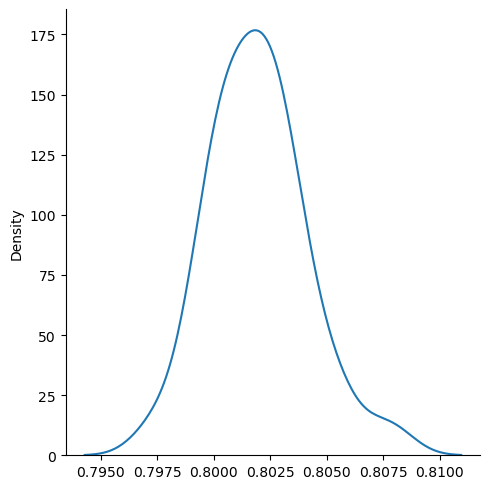

In [34]:
sns.displot(resultados_random_forest, kind = 'kde')

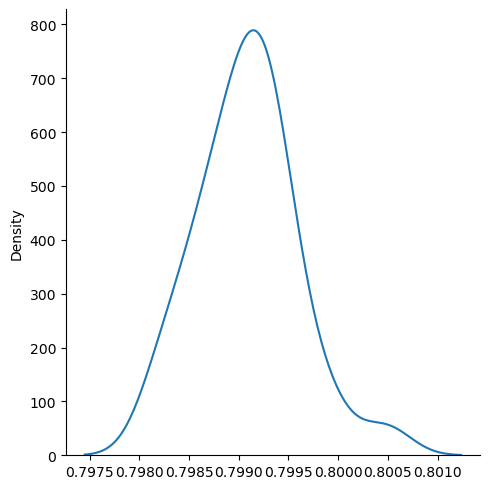

In [35]:
sns.displot(resultados_svm, kind = 'kde')

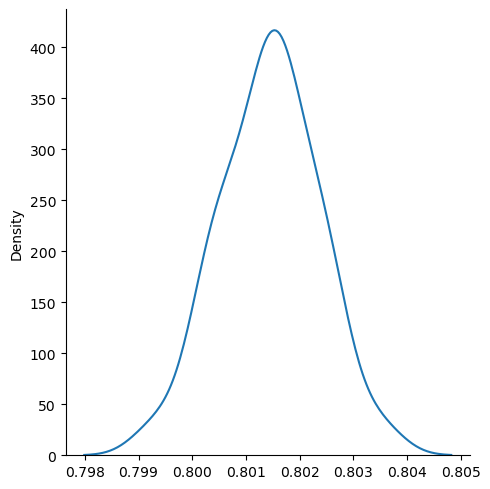

In [36]:
sns.displot(resultados_rede_neural, kind = 'kde')

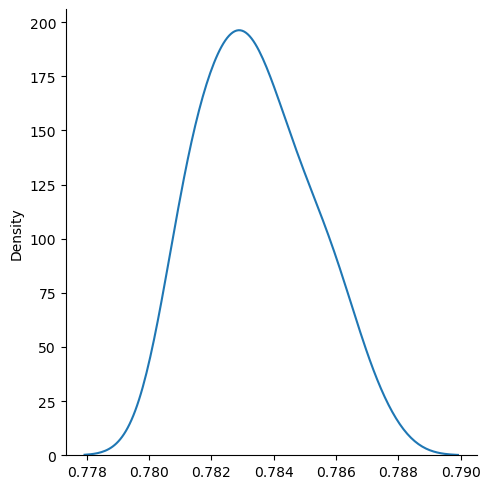

In [37]:
sns.displot(resultados_knn, kind = 'kde')

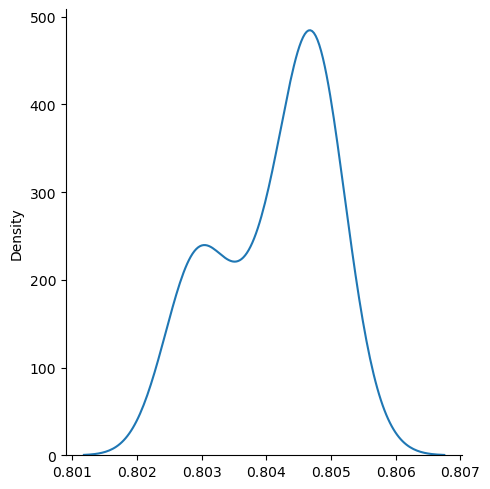

In [38]:
sns.displot(resultados_logistica, kind = 'kde')

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Re-treino dos modelos com melhores parâmetros
Retreinando com os parâmetros encontrados no GridSearch, usando `X_treino/X_teste` para avaliação justa.

In [13]:
# Dicionário com os modelos e seus melhores parâmetros
modelos = {
    'Random Forest': RandomForestClassifier(
        criterion='entropy', min_samples_leaf=10,
        min_samples_split=2, n_estimators=40
    ),
    'SVM': SVC(
        C=2.0, kernel='linear', tol=0.001, probability=True
    ),
    'Rede Neural': MLPClassifier(
        activation='logistic', batch_size=56,
        solver='sgd', max_iter=1000
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=20, p=1
    ),
    'Logística': LogisticRegression(
        C=2.0, solver='saga', tol=0.0001, max_iter=5000
    ),
    'Naive Bayes': GaussianNB()
}

# Treinar e gerar predições
predicoes = {}
probabilidades = {}

for nome, modelo in modelos.items():
    modelo.fit(X_treino, y_treino)
    predicoes[nome] = modelo.predict(X_teste)
    
    # Probabilidades para ROC-AUC
    if hasattr(modelo, 'predict_proba'):
        probabilidades[nome] = modelo.predict_proba(X_teste)[:, 1]
    elif hasattr(modelo, 'decision_function'):
        probabilidades[nome] = modelo.decision_function(X_teste)
    
print('Modelos treinados com sucesso!')

Modelos treinados com sucesso!


## Tabela Comparativa de Métricas

In [14]:
metricas = []

for nome in modelos:
    y_pred = predicoes[nome]
    
    acc = accuracy_score(y_teste, y_pred)
    prec = precision_score(y_teste, y_pred)
    rec = recall_score(y_teste, y_pred)
    f1 = f1_score(y_teste, y_pred)
    
    # ROC-AUC
    if nome in probabilidades:
        roc_auc = roc_auc_score(y_teste, probabilidades[nome])
    else:
        roc_auc = np.nan
    
    metricas.append({
        'Modelo': nome,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4) if not np.isnan(roc_auc) else '-'
    })

df_metricas = pd.DataFrame(metricas).set_index('Modelo')
df_metricas.style.highlight_max(axis=0, color='lightgreen')

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Random Forest,0.795300,0.651400,0.494700,0.562300,0.834200
SVM,0.795300,0.636100,0.537400,0.582600,0.818600
Rede Neural,0.786100,0.611600,0.534800,0.570600,0.828300
KNN,0.770400,0.573900,0.529400,0.550800,0.810800
Logística,0.788900,0.624600,0.516000,0.565200,0.831800
Naive Bayes,0.683700,0.449400,0.842200,0.586000,0.810700


## Classification Report Detalhado (por modelo)

In [30]:
for nome in modelos:
    print(f"{'='*60}")
    print(f"  {nome}")
    print(f"{'='*60}")
    print(classification_report(
        y_teste, predicoes[nome],
        target_names=['Não Churn (0)', 'Churn (1)']
    ))
    print()

  Random Forest
               precision    recall  f1-score   support

Não Churn (0)       0.82      0.92      0.87      1033
    Churn (1)       0.67      0.46      0.55       374

     accuracy                           0.80      1407
    macro avg       0.75      0.69      0.71      1407
 weighted avg       0.78      0.80      0.78      1407


  SVM
               precision    recall  f1-score   support

Não Churn (0)       0.84      0.89      0.86      1033
    Churn (1)       0.64      0.54      0.58       374

     accuracy                           0.80      1407
    macro avg       0.74      0.71      0.72      1407
 weighted avg       0.79      0.80      0.79      1407


  Rede Neural
               precision    recall  f1-score   support

Não Churn (0)       0.84      0.88      0.86      1033
    Churn (1)       0.62      0.53      0.57       374

     accuracy                           0.79      1407
    macro avg       0.73      0.71      0.71      1407
 weighted avg      

## Matrizes de Confusão

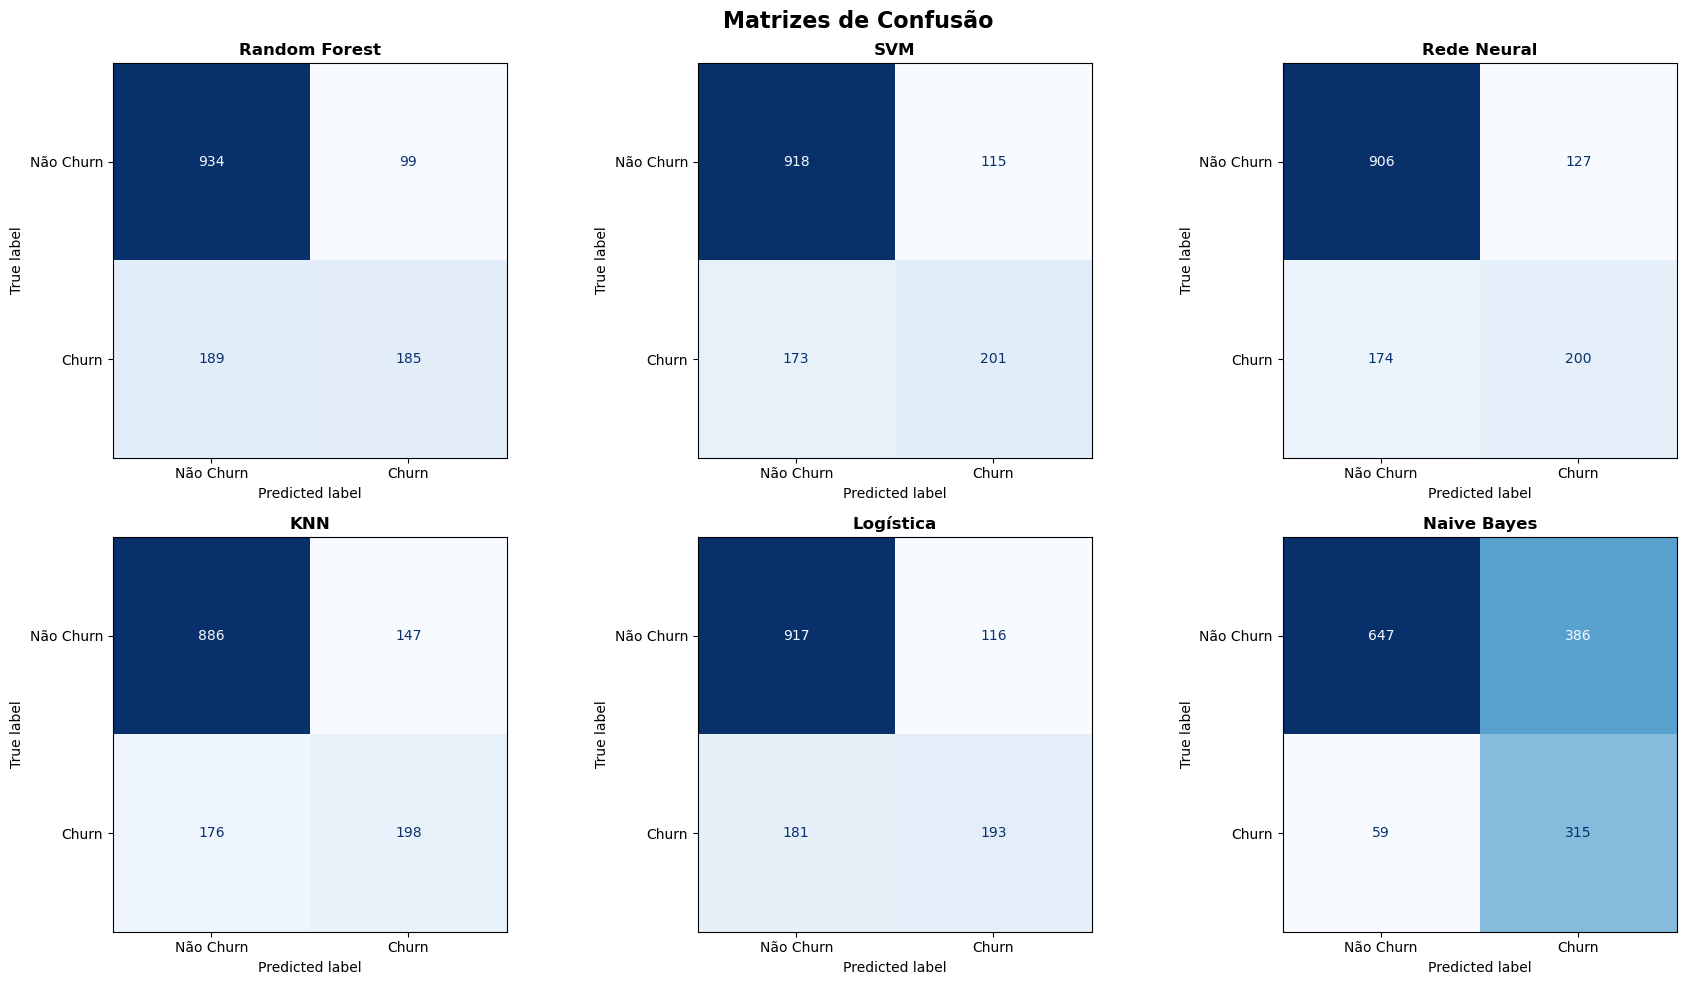

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Matrizes de Confusão', fontsize=16, fontweight='bold')

for ax, nome in zip(axes.flatten(), modelos):
    cm = confusion_matrix(y_teste, predicoes[nome])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Não Churn', 'Churn']
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(nome, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Curvas ROC-AUC

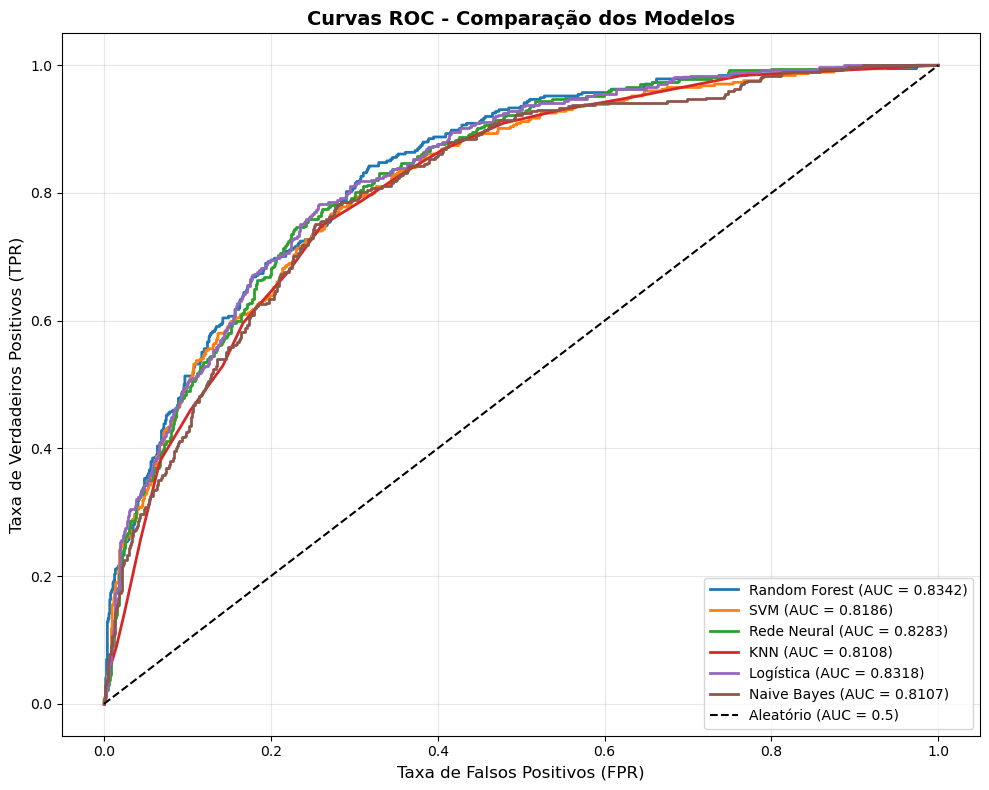

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))

cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for (nome, proba), cor in zip(probabilidades.items(), cores):
    fpr, tpr, _ = roc_curve(y_teste, proba)
    auc_val = roc_auc_score(y_teste, proba)
    ax.plot(fpr, tpr, color=cor, lw=2,
            label=f'{nome} (AUC = {auc_val:.4f})')

# Linha diagonal (classificador aleatório)
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Aleatório (AUC = 0.5)')

ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC - Comparação dos Modelos', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Análise de ROI (Return on Investment)

Simulação do impacto financeiro de cada modelo no contexto de churn.

**Premissas:**
- Custo médio de aquisição de novo cliente: **R$ 500**
- Custo de campanha de retenção por cliente: **R$ 100**
- Receita média anual por cliente retido: **R$ 1.200**
- Taxa de sucesso da campanha de retenção: **50%**

In [18]:
# Parâmetros de ROI
CUSTO_AQUISICAO = 500      # Custo para adquirir um novo cliente
CUSTO_RETENCAO = 100       # Custo da campanha de retenção por cliente
RECEITA_ANUAL = 1200       # Receita média anual por cliente
TAXA_SUCESSO_RETENCAO = 0.5  # Probabilidade de reter o cliente com a campanha

roi_resultados = []

for nome in modelos:
    y_pred = predicoes[nome]
    cm = confusion_matrix(y_teste, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # TP: Churn previsto corretamente → cliente retido com campanha
    clientes_retidos = tp * TAXA_SUCESSO_RETENCAO
    receita_salva = clientes_retidos * RECEITA_ANUAL
    
    # FN: Churn não detectado → cliente perdido → custo de aquisição de substituto
    custo_churn_nao_detectado = fn * CUSTO_AQUISICAO
    
    # FP: Falso alarme → campanha desnecessária (custo sem retorno)
    custo_falso_alarme = fp * CUSTO_RETENCAO
    
    # Custo total da campanha (para todos os previstos como churn: TP + FP)
    custo_campanha = (tp + fp) * CUSTO_RETENCAO
    
    # Benefício líquido
    beneficio = receita_salva - custo_campanha - custo_churn_nao_detectado
    
    # ROI = (Benefício - Custo) / Custo
    if custo_campanha > 0:
        roi = ((receita_salva - custo_campanha) / custo_campanha) * 100
    else:
        roi = 0
    
    roi_resultados.append({
        'Modelo': nome,
        'TP (Churn Detectado)': tp,
        'FN (Churn Não Detectado)': fn,
        'FP (Falso Alarme)': fp,
        'Clientes Retidos': int(clientes_retidos),
        'Receita Salva (R$)': f'{receita_salva:,.0f}',
        'Custo Campanha (R$)': f'{custo_campanha:,.0f}',
        'Custo Churn Perdido (R$)': f'{custo_churn_nao_detectado:,.0f}',
        'Benefício Líquido (R$)': f'{beneficio:,.0f}',
        'ROI (%)': f'{roi:.1f}%'
    })

df_roi = pd.DataFrame(roi_resultados).set_index('Modelo')
df_roi

,TP (Churn Detectado),FN (Churn Não Detectado),FP (Falso Alarme),Clientes Retidos,Receita Salva (R$),Custo Campanha (R$),Custo Churn Perdido (R$),Benefício Líquido (R$),ROI (%)
Modelo,,,,,,,,,
Random Forest,185,189,99,92,"111,000","28,400","94,500","-11,900",290.8%
SVM,201,173,115,100,"120,600","31,600","86,500","2,500",281.6%
Rede Neural,200,174,127,100,"120,000","32,700","87,000",300,267.0%
KNN,198,176,147,99,"118,800","34,500","88,000","-3,700",244.3%
Logística,193,181,116,96,"115,800","30,900","90,500","-5,600",274.8%
Naive Bayes,315,59,386,157,"189,000","70,100","29,500","89,400",169.6%


## Visualização do ROI e Benefício Líquido

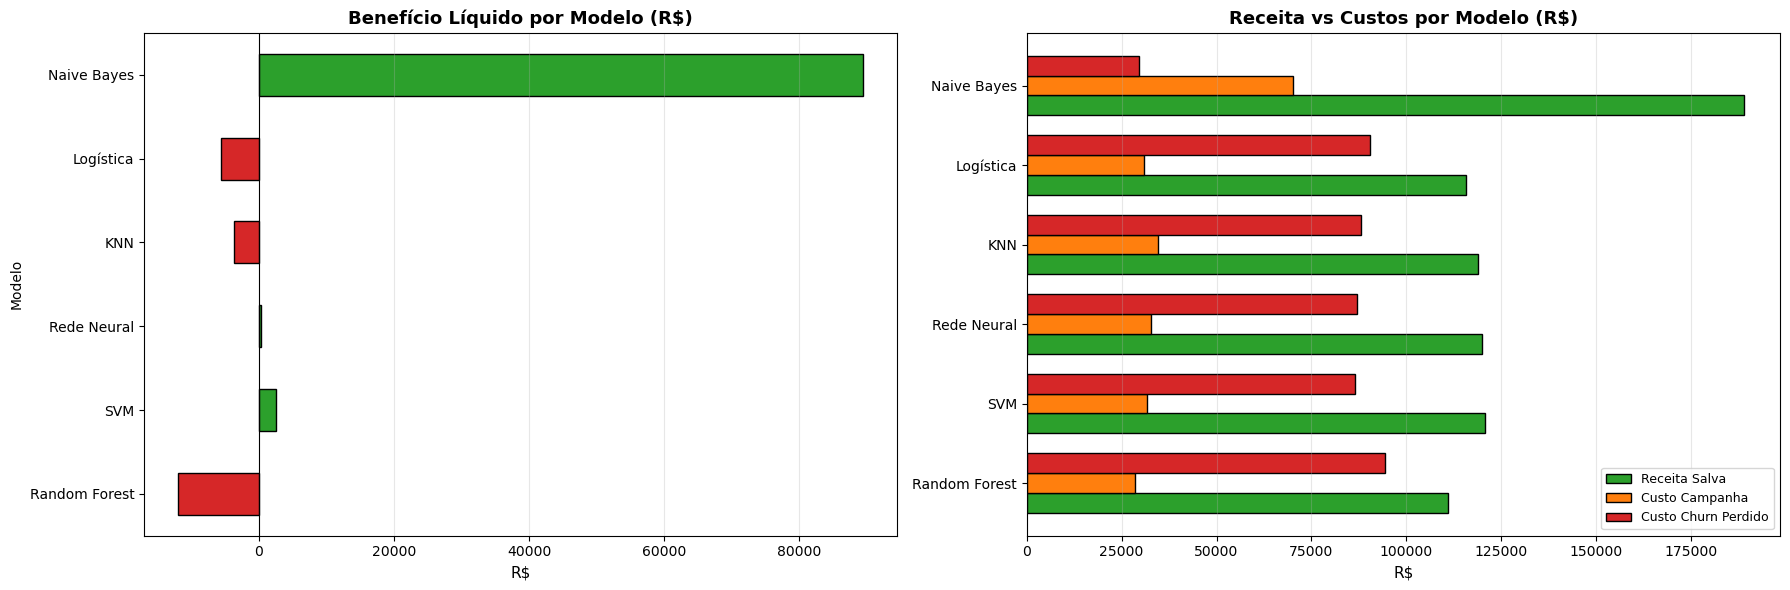

In [19]:
# Preparar dados numéricos para o gráfico
roi_plot = []
for nome in modelos:
    y_pred = predicoes[nome]
    cm = confusion_matrix(y_teste, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    clientes_retidos = tp * TAXA_SUCESSO_RETENCAO
    receita_salva = clientes_retidos * RECEITA_ANUAL
    custo_campanha = (tp + fp) * CUSTO_RETENCAO
    custo_churn_perdido = fn * CUSTO_AQUISICAO
    beneficio = receita_salva - custo_campanha - custo_churn_perdido
    
    roi_plot.append({
        'Modelo': nome,
        'Receita Salva': receita_salva,
        'Custo Campanha': -custo_campanha,
        'Custo Churn Perdido': -custo_churn_perdido,
        'Benefício Líquido': beneficio
    })

df_roi_plot = pd.DataFrame(roi_plot).set_index('Modelo')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: Benefício Líquido
cores_beneficio = ['#2ca02c' if v >= 0 else '#d62728' for v in df_roi_plot['Benefício Líquido']]
df_roi_plot['Benefício Líquido'].plot(
    kind='barh', ax=axes[0], color=cores_beneficio, edgecolor='black'
)
axes[0].set_title('Benefício Líquido por Modelo (R$)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('R$', fontsize=11)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].grid(True, alpha=0.3, axis='x')

# Gráfico 2: Receita Salva vs Custos
x = np.arange(len(df_roi_plot))
width = 0.25
axes[1].barh(x - width, df_roi_plot['Receita Salva'], width,
             label='Receita Salva', color='#2ca02c', edgecolor='black')
axes[1].barh(x, df_roi_plot['Custo Campanha'].abs(), width,
             label='Custo Campanha', color='#ff7f0e', edgecolor='black')
axes[1].barh(x + width, df_roi_plot['Custo Churn Perdido'].abs(), width,
             label='Custo Churn Perdido', color='#d62728', edgecolor='black')
axes[1].set_yticks(x)
axes[1].set_yticklabels(df_roi_plot.index)
axes[1].set_title('Receita vs Custos por Modelo (R$)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('R$', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Resumo: Melhor Modelo por Métrica

In [20]:
# Converter colunas numéricas para float
df_metricas_num = df_metricas.copy()
for col in df_metricas_num.columns:
    df_metricas_num[col] = pd.to_numeric(df_metricas_num[col], errors='coerce')

print('🏆 MELHOR MODELO POR MÉTRICA:')
print('=' * 50)
for col in df_metricas_num.columns:
    melhor = df_metricas_num[col].idxmax()
    valor = df_metricas_num[col].max()
    print(f'  {col:12s} → {melhor:20s} ({valor:.4f})')

print(f"\n{'=' * 50}")
print('\n📌 Nota: Para problemas de Churn, Recall é especialmente\n'
      '   importante pois indica a capacidade de detectar clientes\n'
      '   que realmente vão sair (minimizar falsos negativos).\n'
      '   ROC-AUC mede a capacidade geral de discriminação do modelo.')

🏆 MELHOR MODELO POR MÉTRICA:
  Accuracy     → Random Forest        (0.7953)
  Precision    → Random Forest        (0.6514)
  Recall       → Naive Bayes          (0.8422)
  F1-Score     → Naive Bayes          (0.5860)
  ROC-AUC      → Random Forest        (0.8342)


📌 Nota: Para problemas de Churn, Recall é especialmente
   importante pois indica a capacidade de detectar clientes
   que realmente vão sair (minimizar falsos negativos).
   ROC-AUC mede a capacidade geral de discriminação do modelo.


# Métricas de Avaliação dos Modelos

Avaliação completa com: **Accuracy, Precision, Recall, F1-Score, ROC-AUC e ROI**

In [21]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Re-treino dos modelos com melhores parâmetros
Retreinando com os parâmetros encontrados no GridSearch, usando `X_treino/X_teste` para avaliação justa.

In [22]:
# Dicionário com os modelos e seus melhores parâmetros
modelos = {
    'Random Forest': RandomForestClassifier(
        criterion='entropy', min_samples_leaf=10,
        min_samples_split=2, n_estimators=40
    ),
    'SVM': SVC(
        C=2.0, kernel='linear', tol=0.001, probability=True
    ),
    'Rede Neural': MLPClassifier(
        activation='logistic', batch_size=56,
        solver='sgd', max_iter=1000
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=20, p=1
    ),
    'Logística': LogisticRegression(
        C=2.0, solver='saga', tol=0.0001, max_iter=5000
    ),
    'Naive Bayes': GaussianNB()
}

# Treinar e gerar predições
predicoes = {}
probabilidades = {}

for nome, modelo in modelos.items():
    modelo.fit(X_treino, y_treino)
    predicoes[nome] = modelo.predict(X_teste)
    
    # Probabilidades para ROC-AUC
    if hasattr(modelo, 'predict_proba'):
        probabilidades[nome] = modelo.predict_proba(X_teste)[:, 1]
    elif hasattr(modelo, 'decision_function'):
        probabilidades[nome] = modelo.decision_function(X_teste)
    
print('Modelos treinados com sucesso!')

Modelos treinados com sucesso!


## Tabela Comparativa de Métricas

In [23]:
metricas = []

for nome in modelos:
    y_pred = predicoes[nome]
    
    acc = accuracy_score(y_teste, y_pred)
    prec = precision_score(y_teste, y_pred)
    rec = recall_score(y_teste, y_pred)
    f1 = f1_score(y_teste, y_pred)
    
    # ROC-AUC
    if nome in probabilidades:
        roc_auc = roc_auc_score(y_teste, probabilidades[nome])
    else:
        roc_auc = np.nan
    
    metricas.append({
        'Modelo': nome,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4) if not np.isnan(roc_auc) else '-'
    })

df_metricas = pd.DataFrame(metricas).set_index('Modelo')
df_metricas.style.highlight_max(axis=0, color='lightgreen')

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Random Forest,0.795300,0.665400,0.462600,0.545700,0.830800
SVM,0.795300,0.636100,0.537400,0.582600,0.818600
Rede Neural,0.787500,0.616800,0.529400,0.569800,0.828100
KNN,0.770400,0.573900,0.529400,0.550800,0.810800
Logística,0.788900,0.624600,0.516000,0.565200,0.831800
Naive Bayes,0.683700,0.449400,0.842200,0.586000,0.810700


## Classification Report Detalhado (por modelo)

In [24]:
for nome in modelos:
    print(f"{'='*60}")
    print(f"  {nome}")
    print(f"{'='*60}")
    print(classification_report(
        y_teste, predicoes[nome],
        target_names=['Não Churn (0)', 'Churn (1)']
    ))
    print()

  Random Forest
               precision    recall  f1-score   support

Não Churn (0)       0.82      0.92      0.87      1033
    Churn (1)       0.67      0.46      0.55       374

     accuracy                           0.80      1407
    macro avg       0.75      0.69      0.71      1407
 weighted avg       0.78      0.80      0.78      1407


  SVM
               precision    recall  f1-score   support

Não Churn (0)       0.84      0.89      0.86      1033
    Churn (1)       0.64      0.54      0.58       374

     accuracy                           0.80      1407
    macro avg       0.74      0.71      0.72      1407
 weighted avg       0.79      0.80      0.79      1407


  Rede Neural
               precision    recall  f1-score   support

Não Churn (0)       0.84      0.88      0.86      1033
    Churn (1)       0.62      0.53      0.57       374

     accuracy                           0.79      1407
    macro avg       0.73      0.71      0.71      1407
 weighted avg      

## Matrizes de Confusão

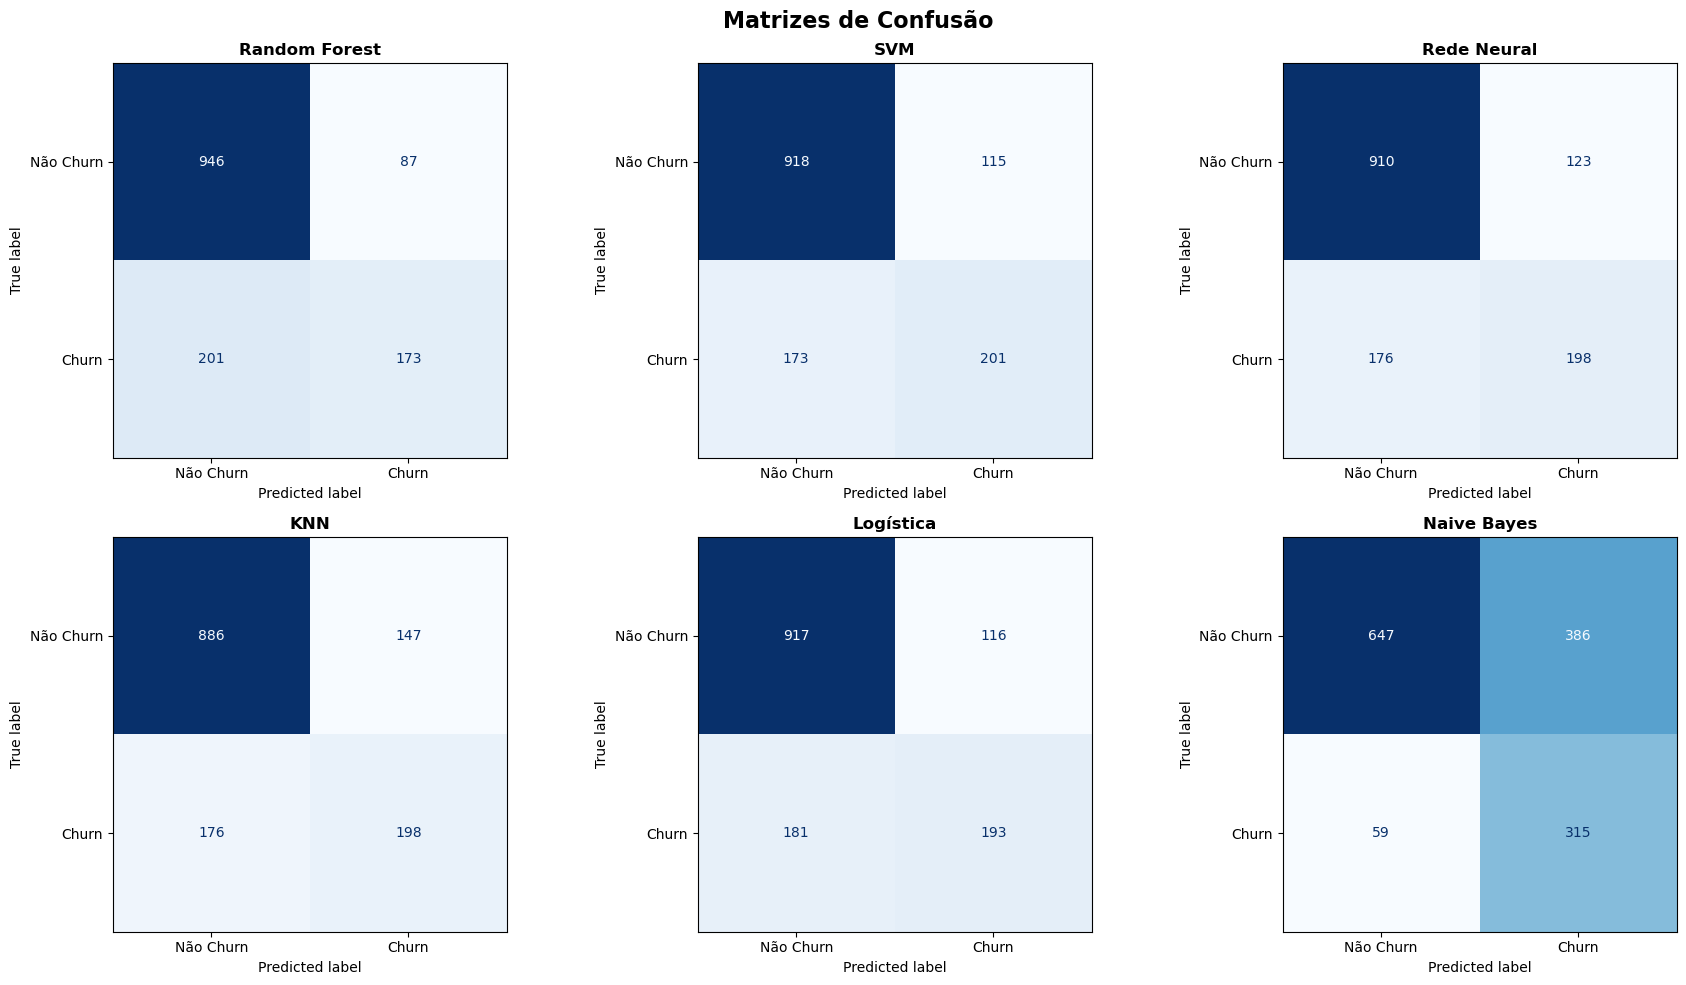

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Matrizes de Confusão', fontsize=16, fontweight='bold')

for ax, nome in zip(axes.flatten(), modelos):
    cm = confusion_matrix(y_teste, predicoes[nome])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Não Churn', 'Churn']
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(nome, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Curvas ROC-AUC

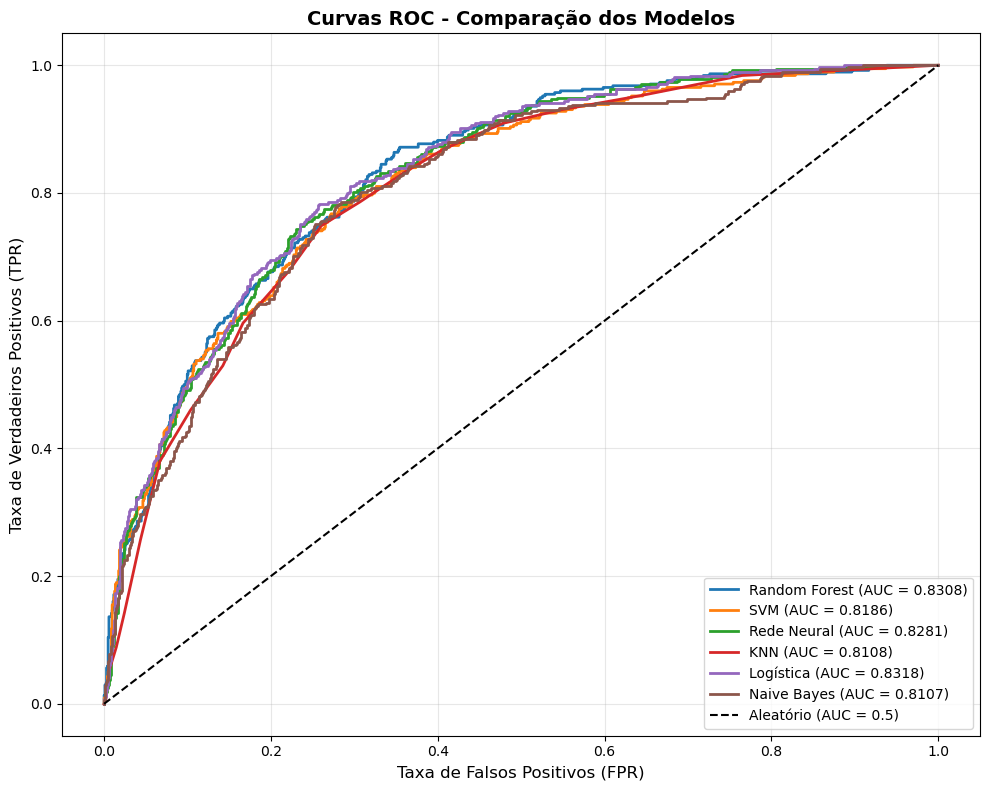

In [26]:
fig, ax = plt.subplots(figsize=(10, 8))

cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for (nome, proba), cor in zip(probabilidades.items(), cores):
    fpr, tpr, _ = roc_curve(y_teste, proba)
    auc_val = roc_auc_score(y_teste, proba)
    ax.plot(fpr, tpr, color=cor, lw=2,
            label=f'{nome} (AUC = {auc_val:.4f})')

# Linha diagonal (classificador aleatório)
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Aleatório (AUC = 0.5)')

ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC - Comparação dos Modelos', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Análise de ROI (Return on Investment)

Simulação do impacto financeiro de cada modelo no contexto de churn.

**Premissas:**
- Custo médio de aquisição de novo cliente: **R$ 500**
- Custo de campanha de retenção por cliente: **R$ 100**
- Receita média anual por cliente retido: **R$ 1.200**
- Taxa de sucesso da campanha de retenção: **50%**

In [27]:
# Parâmetros de ROI
CUSTO_AQUISICAO = 500      # Custo para adquirir um novo cliente
CUSTO_RETENCAO = 100       # Custo da campanha de retenção por cliente
RECEITA_ANUAL = 1200       # Receita média anual por cliente
TAXA_SUCESSO_RETENCAO = 0.5  # Probabilidade de reter o cliente com a campanha

roi_resultados = []

for nome in modelos:
    y_pred = predicoes[nome]
    cm = confusion_matrix(y_teste, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # TP: Churn previsto corretamente → cliente retido com campanha
    clientes_retidos = tp * TAXA_SUCESSO_RETENCAO
    receita_salva = clientes_retidos * RECEITA_ANUAL
    
    # FN: Churn não detectado → cliente perdido → custo de aquisição de substituto
    custo_churn_nao_detectado = fn * CUSTO_AQUISICAO
    
    # FP: Falso alarme → campanha desnecessária (custo sem retorno)
    custo_falso_alarme = fp * CUSTO_RETENCAO
    
    # Custo total da campanha (para todos os previstos como churn: TP + FP)
    custo_campanha = (tp + fp) * CUSTO_RETENCAO
    
    # Benefício líquido
    beneficio = receita_salva - custo_campanha - custo_churn_nao_detectado
    
    # ROI = (Benefício - Custo) / Custo
    if custo_campanha > 0:
        roi = ((receita_salva - custo_campanha) / custo_campanha) * 100
    else:
        roi = 0
    
    roi_resultados.append({
        'Modelo': nome,
        'TP (Churn Detectado)': tp,
        'FN (Churn Não Detectado)': fn,
        'FP (Falso Alarme)': fp,
        'Clientes Retidos': int(clientes_retidos),
        'Receita Salva (R$)': f'{receita_salva:,.0f}',
        'Custo Campanha (R$)': f'{custo_campanha:,.0f}',
        'Custo Churn Perdido (R$)': f'{custo_churn_nao_detectado:,.0f}',
        'Benefício Líquido (R$)': f'{beneficio:,.0f}',
        'ROI (%)': f'{roi:.1f}%'
    })

df_roi = pd.DataFrame(roi_resultados).set_index('Modelo')
df_roi

,TP (Churn Detectado),FN (Churn Não Detectado),FP (Falso Alarme),Clientes Retidos,Receita Salva (R$),Custo Campanha (R$),Custo Churn Perdido (R$),Benefício Líquido (R$),ROI (%)
Modelo,,,,,,,,,
Random Forest,173,201,87,86,"103,800","26,000","100,500","-22,700",299.2%
SVM,201,173,115,100,"120,600","31,600","86,500","2,500",281.6%
Rede Neural,198,176,123,99,"118,800","32,100","88,000","-1,300",270.1%
KNN,198,176,147,99,"118,800","34,500","88,000","-3,700",244.3%
Logística,193,181,116,96,"115,800","30,900","90,500","-5,600",274.8%
Naive Bayes,315,59,386,157,"189,000","70,100","29,500","89,400",169.6%


## Visualização do ROI e Benefício Líquido

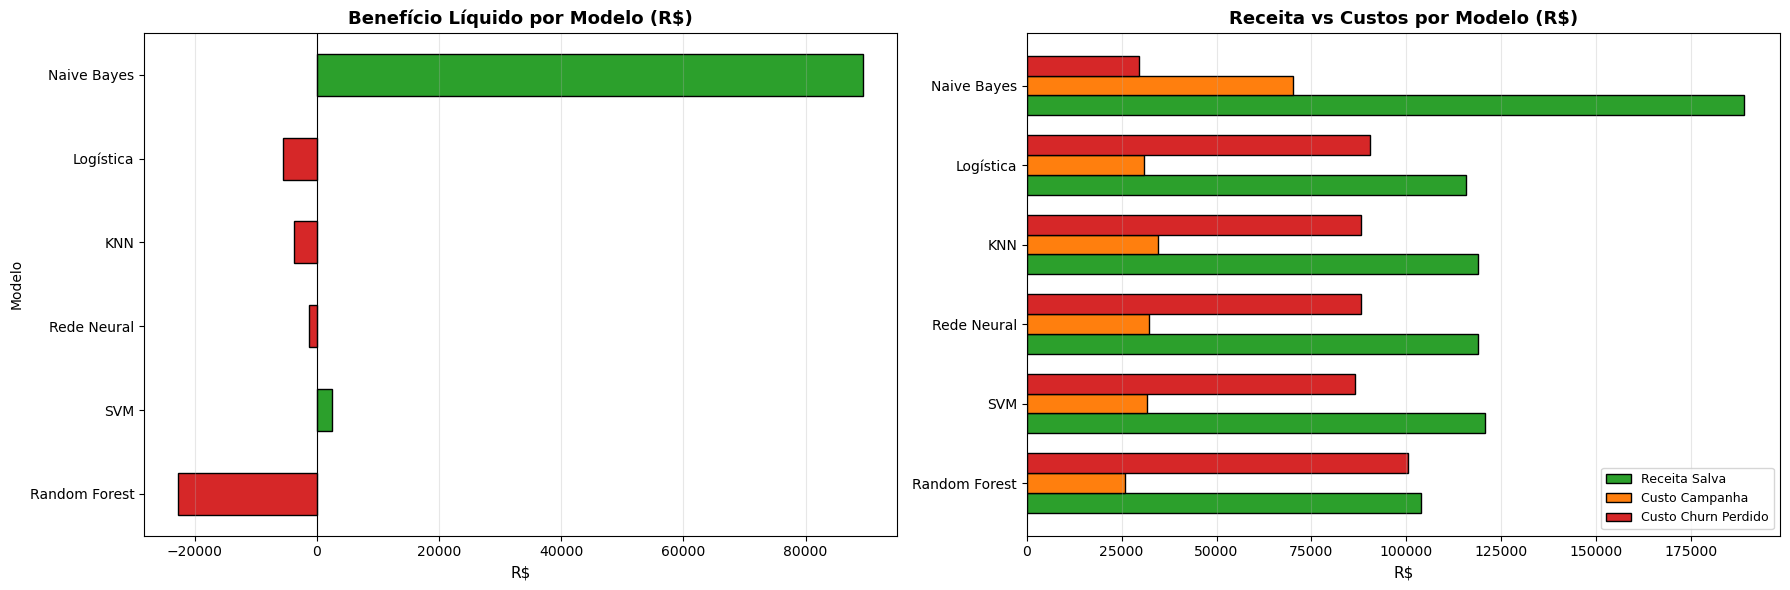

In [28]:
# Preparar dados numéricos para o gráfico
roi_plot = []
for nome in modelos:
    y_pred = predicoes[nome]
    cm = confusion_matrix(y_teste, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    clientes_retidos = tp * TAXA_SUCESSO_RETENCAO
    receita_salva = clientes_retidos * RECEITA_ANUAL
    custo_campanha = (tp + fp) * CUSTO_RETENCAO
    custo_churn_perdido = fn * CUSTO_AQUISICAO
    beneficio = receita_salva - custo_campanha - custo_churn_perdido
    
    roi_plot.append({
        'Modelo': nome,
        'Receita Salva': receita_salva,
        'Custo Campanha': -custo_campanha,
        'Custo Churn Perdido': -custo_churn_perdido,
        'Benefício Líquido': beneficio
    })

df_roi_plot = pd.DataFrame(roi_plot).set_index('Modelo')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: Benefício Líquido
cores_beneficio = ['#2ca02c' if v >= 0 else '#d62728' for v in df_roi_plot['Benefício Líquido']]
df_roi_plot['Benefício Líquido'].plot(
    kind='barh', ax=axes[0], color=cores_beneficio, edgecolor='black'
)
axes[0].set_title('Benefício Líquido por Modelo (R$)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('R$', fontsize=11)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].grid(True, alpha=0.3, axis='x')

# Gráfico 2: Receita Salva vs Custos
x = np.arange(len(df_roi_plot))
width = 0.25
axes[1].barh(x - width, df_roi_plot['Receita Salva'], width,
             label='Receita Salva', color='#2ca02c', edgecolor='black')
axes[1].barh(x, df_roi_plot['Custo Campanha'].abs(), width,
             label='Custo Campanha', color='#ff7f0e', edgecolor='black')
axes[1].barh(x + width, df_roi_plot['Custo Churn Perdido'].abs(), width,
             label='Custo Churn Perdido', color='#d62728', edgecolor='black')
axes[1].set_yticks(x)
axes[1].set_yticklabels(df_roi_plot.index)
axes[1].set_title('Receita vs Custos por Modelo (R$)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('R$', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Resumo: Melhor Modelo por Métrica

In [29]:
# Converter colunas numéricas para float
df_metricas_num = df_metricas.copy()
for col in df_metricas_num.columns:
    df_metricas_num[col] = pd.to_numeric(df_metricas_num[col], errors='coerce')

print('🏆 MELHOR MODELO POR MÉTRICA:')
print('=' * 50)
for col in df_metricas_num.columns:
    melhor = df_metricas_num[col].idxmax()
    valor = df_metricas_num[col].max()
    print(f'  {col:12s} → {melhor:20s} ({valor:.4f})')

print(f"\n{'=' * 50}")
print('\n📌 Nota: Para problemas de Churn, Recall é especialmente\n'
      '   importante pois indica a capacidade de detectar clientes\n'
      '   que realmente vão sair (minimizar falsos negativos).\n'
      '   ROC-AUC mede a capacidade geral de discriminação do modelo.')

🏆 MELHOR MODELO POR MÉTRICA:
  Accuracy     → Random Forest        (0.7953)
  Precision    → Random Forest        (0.6654)
  Recall       → Naive Bayes          (0.8422)
  F1-Score     → Naive Bayes          (0.5860)
  ROC-AUC      → Logística            (0.8318)


📌 Nota: Para problemas de Churn, Recall é especialmente
   importante pois indica a capacidade de detectar clientes
   que realmente vão sair (minimizar falsos negativos).
   ROC-AUC mede a capacidade geral de discriminação do modelo.
